In [1]:
x_train = catalog.load("X_train_linear")

[12/31/23 00:13:53] INFO     Loading data from 'X_train_linear' (ParquetDataSet)...             ]8;id=622946;file:///Users/air/Desktop/BetaStar/env/lib/python3.10/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=741286;file:///Users/air/Desktop/BetaStar/env/lib/python3.10/site-packages/kedro/io/data_catalog.py#345\345]8;;\

In [2]:
x_train.head()

,participation,in_mod_deg,beta_star,edge_contr,cada,kl,l1,l2,hd,kl2,...,emb_struc2vec_7,emb_struc2vec_8,emb_struc2vec_9,emb_struc2vec_10,emb_struc2vec_11,emb_struc2vec_12,emb_struc2vec_13,emb_struc2vec_14,emb_struc2vec_15,emb_struc2vec_16
0,0.206612,-0.314158,0.269312,0.363636,2.750000,1.082993,1.139982,0.358881,0.604868,0.205555,...,0.733384,-0.646952,-0.637106,0.107838,-0.759791,0.077197,-1.148768,-0.029066,0.437203,0.013202
1,0.680000,-0.345652,0.719270,0.800000,1.250000,2.387565,1.812800,0.778092,0.833917,1.202136,...,0.181004,-0.085013,0.162654,0.163570,0.565595,-0.131315,-0.926381,0.395095,-0.121341,-0.102204
2,0.629630,-0.094546,0.682696,0.777778,1.285714,1.801758,1.538778,0.716379,0.743423,1.159456,...,0.043138,0.117764,-0.293331,0.483194,-0.415933,0.802586,-0.314098,1.116077,0.675419,-0.476713
3,0.551020,-0.279624,0.700308,0.714286,1.400000,3.145596,1.796600,0.751529,0.863883,1.430369,...,0.008313,0.153767,0.135505,-0.748303,-0.153482,0.445924,-0.630636,1.013393,0.538712,-0.007311
4,0.722222,-0.277679,0.822604,0.833333,1.200000,3.584550,1.796400,0.855435,0.880300,1.405000,...,0.494483,-0.544962,0.126461,-0.453691,-0.861371,0.650186,0.448591,0.609057,-1.151201,-0.199012


In [3]:
from sklearn.feature_selection import mutual_info_regression

In [4]:
TARGET_LIST = [
    "cada",
    "edge_contr",
    "in_mod_deg",
    "participation",
    "beta_star",
    "l1",
    "l2",
    "kl",
    "hd",
    "l12",
    "l22",
    "kl2",
    "hd2",
]
x_tr = x_train.drop(TARGET_LIST, axis=1)
X = x_tr.copy()
y = x_train['beta_star']

In [10]:
import pandas as pd


def make_mi_scores(X, y, discrete_features=False):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

In [11]:
wynik = make_mi_scores(X,y)

In [12]:
wynik[:20]


dc                  1.683405
lcc                 0.808558
core                0.561124
emb_struc2vec_3     0.330390
bc                  0.330275
emb_struc2vec_4     0.241584
emb_struc2vec_5     0.226828
emb_struc2vec_13    0.219574
emb_struc2vec_15    0.199330
emb_struc2vec_10    0.198737
emb_struc2vec_11    0.181534
ec                  0.179940
emb_struc2vec_14    0.178942
emb_struc2vec_2     0.169195
emb_struc2vec_12    0.165969
emb_struc2vec_6     0.151806
cc                  0.146087
emb_struc2vec_9     0.145925
emb_struc2vec_8     0.142247
emb_struc2vec_16    0.128623
Name: MI Scores, dtype: float64

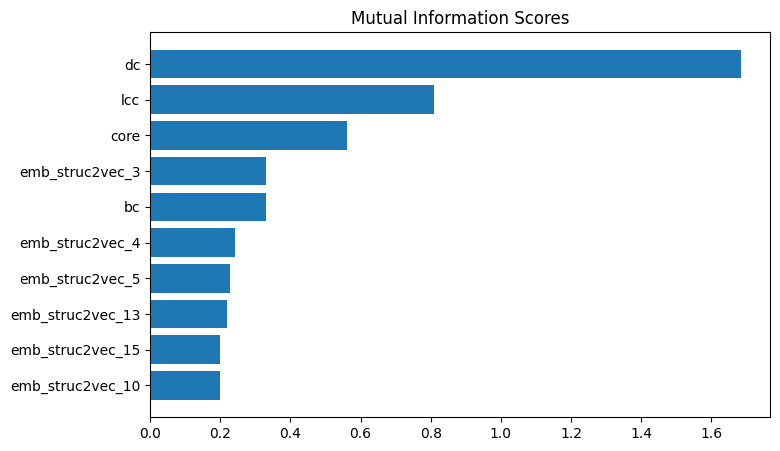

In [16]:
import matplotlib.pyplot as plt
import numpy as np
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")


plt.figure(dpi=100, figsize=(8, 5))
plot_mi_scores(wynik[:10])

[12/31/23 00:17:38] WARNING  /Users/air/Desktop/BetaStar/env/lib/python3.10/site-packages/seaborn/a ]8;id=37598;file:///opt/homebrew/Cellar/python@3.10/3.10.13_1/Frameworks/Python.framework/Versions/3.10/lib/python3.10/warnings.py\warnings.py]8;;\:]8;id=751534;file:///opt/homebrew/Cellar/python@3.10/3.10.13_1/Frameworks/Python.framework/Versions/3.10/lib/python3.10/warnings.py#109\109]8;;\
                             xisgrid.py:123: UserWarning: The figure layout has changed to tight                   
                               self._figure.tight_layout(*args, **kwargs)                                          
                                                                                                                   

                    WARNING  /Users/air/Desktop/BetaStar/env/lib/python3.10/site-packages/seaborn/a ]8;id=144705;file:///opt/homebrew/Cellar/python@3.10/3.10.13_1/Frameworks/Python.framework/Versions/3.10/lib/python3.10/warnings.py\warnings.py]8;;\:]8;id=380027;file:///opt/homebrew/Cellar/python@3.10/3.10.13_1/Frameworks/Python.framework/Versions/3.10/lib/python3.10/warnings.py#109\109]8;;\
                             xisgrid.py:123: UserWarning: The figure layout has changed to tight                   
                               self._figure.tight_layout(*args, **kwargs)                                          
                                                                                                                   

                    WARNING  /Users/air/Desktop/BetaStar/env/lib/python3.10/site-packages/seaborn/a ]8;id=400828;file:///opt/homebrew/Cellar/python@3.10/3.10.13_1/Frameworks/Python.framework/Versions/3.10/lib/python3.10/warnings.py\warnings.py]8;;\:]8;id=490863;file:///opt/homebrew/Cellar/python@3.10/3.10.13_1/Frameworks/Python.framework/Versions/3.10/lib/python3.10/warnings.py#109\109]8;;\
                             xisgrid.py:123: UserWarning: The figure layout has changed to tight                   
                               self._figure.tight_layout(*args, **kwargs)                                          
                                                                                                                   

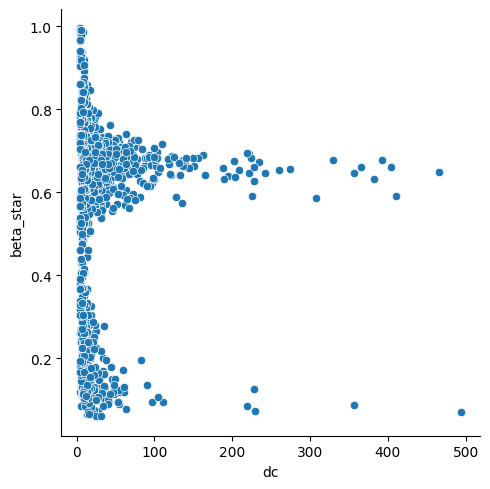

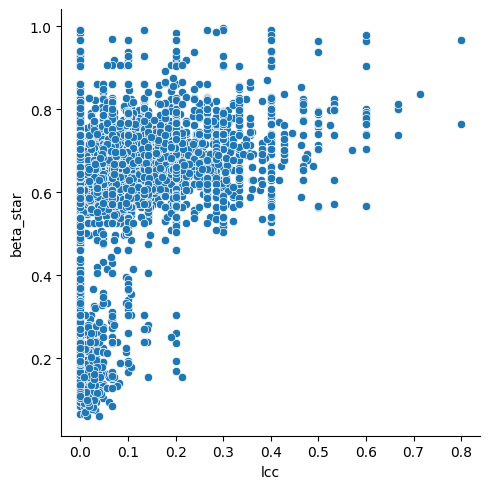

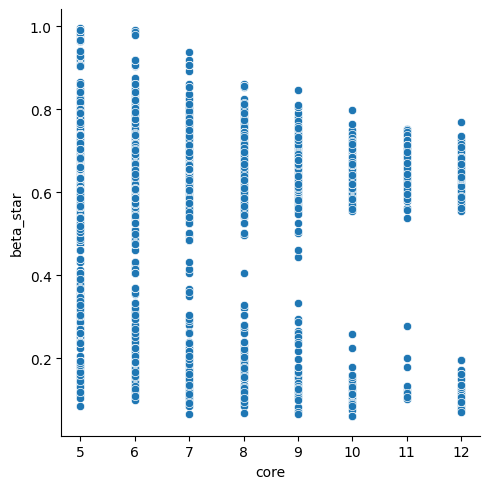

In [23]:
import seaborn as sns
sns.relplot(x="dc", y="beta_star", data=x_train)
sns.relplot(x="lcc", y="beta_star", data=x_train)
sns.relplot(x="core", y="beta_star", data=x_train);

[12/31/23 00:22:00] WARNING  /Users/air/Desktop/BetaStar/env/lib/python3.10/site-packages/seaborn/a ]8;id=194185;file:///opt/homebrew/Cellar/python@3.10/3.10.13_1/Frameworks/Python.framework/Versions/3.10/lib/python3.10/warnings.py\warnings.py]8;;\:]8;id=458540;file:///opt/homebrew/Cellar/python@3.10/3.10.13_1/Frameworks/Python.framework/Versions/3.10/lib/python3.10/warnings.py#109\109]8;;\
                             xisgrid.py:123: UserWarning: The figure layout has changed to tight                   
                               self._figure.tight_layout(*args, **kwargs)                                          
                                                                                                                   

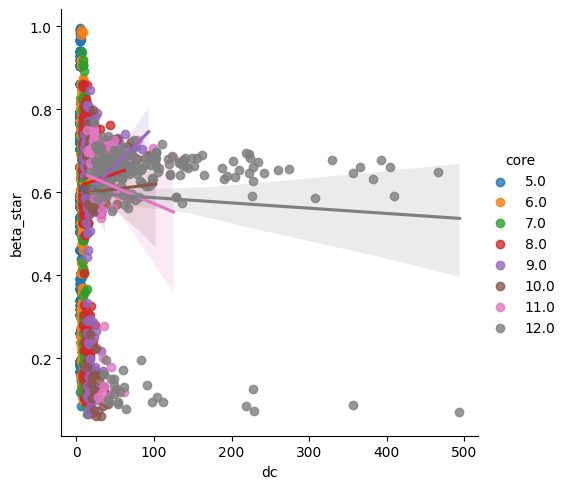

In [26]:
sns.lmplot(x="dc", y="beta_star", hue="core", data=x_train);